# Derivative properties

This notebook continues Course 2, Week 1 by studying where derivatives exist, where they fail to exist, and how derivatives behave when functions are combined.

## Video 1 — Non-differentiable functions

A function is **differentiable at a point** when its derivative exists there. Geometrically, this means the graph has one well-defined tangent line with a finite slope at that point.

A function is differentiable on an interval only when its derivative exists at every point in that interval.

Some graphs fail this test. This lesson introduces three visual warning signs:

1. a corner or cusp;
2. a discontinuity;
3. a vertical tangent.

### Corners and cusps: the absolute-value function

The absolute-value function is

$$
f(x)=|x|
=
\begin{cases}
x, & x\ge0, \\
-x, & x<0.
\end{cases}
$$

Examples include $|7|=7$ and $|-7|=7$.

Away from the origin, each branch is a line:

- for $x<0$, the slope is $-1$;
- for $x>0$, the slope is $1$.

At $x=0$, these two one-sided slopes disagree:

$$
f'_-(0)=-1
\qquad\text{and}\qquad
f'_+(0)=1.
$$

There is no unique tangent slope, so

$$
\boxed{f'(0)\text{ does not exist}.}
$$

The graph is continuous at the origin, but it is not differentiable there because it has a corner.

### Quiz example: a corner at $x=1$

The lecture next shows another graph with a sharp corner and asks where its derivative does not exist. The answer is

$$
x=1.
$$

The exact formula for that graph is not supplied in the transcript, so it is not reconstructed here. The visual test is the same: the slopes approaching the corner from the left and right do not agree, so there is no unique tangent line.

### Jump discontinuity at $x=-1$

The next piecewise graph uses

$$
f(x)=2 \quad\text{for }x<-1
$$

and

$$
f(x)=x+1 \quad\text{for }x>-1.
$$

As $x$ approaches $-1$ from the left, the graph approaches $2$. From the right, it approaches $0$. The two sides do not meet, so the graph has a **jump discontinuity** at $x=-1$.

A differentiable function must be continuous at the point where it is differentiated. Therefore,

$$
\boxed{f\text{ is not differentiable at }x=-1.}
$$

The reverse statement is not guaranteed: a function can be continuous but still fail to be differentiable, as $|x|$ demonstrates.

### Vertical tangent: the cube-root function

Consider

$$
f(x)=x^{1/3}.
$$

At the origin, the graph has a vertical tangent. A vertical line has no finite slope because its horizontal change is zero.

The difference quotient at the origin confirms this:

$$
\frac{f(0+\Delta x)-f(0)}{\Delta x}
=
\frac{(\Delta x)^{1/3}}{\Delta x}
=
\frac1{(\Delta x)^{2/3}}.
$$

As $\Delta x\to0$, this grows without bound rather than approaching a finite number. Therefore,

$$
\boxed{f'(0)\text{ does not exist as a finite derivative}.}
$$

### Visual comparison

The plots below show the three cases from the lesson. The jump graph uses open circles at $x=-1$ because the transcript does not specify which branch, if either, contains the endpoint; that choice does not change the failure of differentiability.

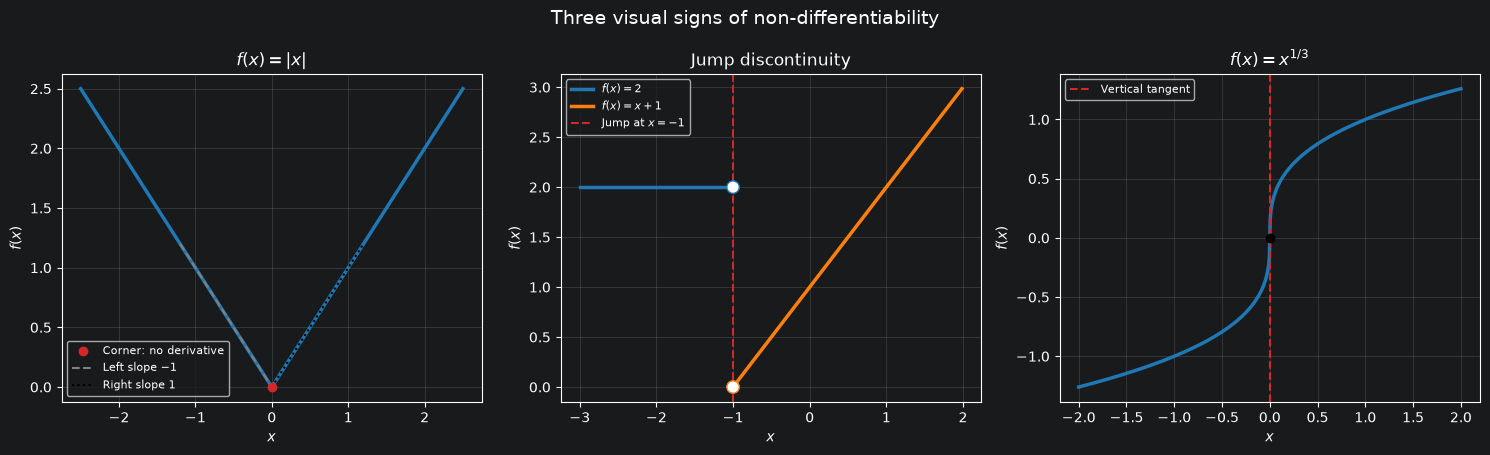

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

absolute_inputs: np.ndarray = np.linspace(-2.5, 2.5, 400)
axes[0].plot(absolute_inputs, np.abs(absolute_inputs), color="tab:blue", linewidth=2.5)
axes[0].scatter([0], [0], color="tab:red", zorder=3, label="Corner: no derivative")
axes[0].plot([-1.2, 0], [1.2, 0], color="gray", linestyle="--", label="Left slope $-1$")
axes[0].plot([0, 1.2], [0, 1.2], color="black", linestyle=":", label="Right slope $1$")
axes[0].set(title="$f(x)=|x|$", xlabel="$x$", ylabel="$f(x)$")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

jump_left_inputs: np.ndarray = np.linspace(-3.0, -1.0, 150, endpoint=False)
jump_right_inputs: np.ndarray = np.linspace(-1.0, 2.0, 200, endpoint=False)[1:]
axes[1].plot(jump_left_inputs, np.full_like(jump_left_inputs, 2.0), color="tab:blue",
             linewidth=2.5, label="$f(x)=2$")
axes[1].plot(jump_right_inputs, jump_right_inputs + 1.0, color="tab:orange", linewidth=2.5,
             label="$f(x)=x+1$")
axes[1].scatter([-1, -1], [2, 0], facecolors="white",
                edgecolors=["tab:blue", "tab:orange"], s=80, zorder=3)
axes[1].axvline(-1, color="tab:red", linestyle="--", label="Jump at $x=-1$")
axes[1].set(title="Jump discontinuity", xlabel="$x$", ylabel="$f(x)$")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

cube_root_inputs: np.ndarray = np.linspace(-2.0, 2.0, 500)
axes[2].plot(cube_root_inputs, np.cbrt(cube_root_inputs), color="tab:blue", linewidth=2.5)
axes[2].axvline(0, color="tab:red", linestyle="--", label="Vertical tangent")
axes[2].scatter([0], [0], color="black", zorder=3)
axes[2].set(title="$f(x)=x^{1/3}$", xlabel="$x$", ylabel="$f(x)$")
axes[2].grid(alpha=0.25)
axes[2].legend(fontsize=8)

fig.suptitle("Three visual signs of non-differentiability", fontsize=14)
fig.tight_layout()
plt.show()

### Recap

| Visual feature | Why the derivative fails |
|---|---|
| Corner or cusp | The left and right tangent slopes do not agree |
| Discontinuity | The graph is not continuous at the point |
| Vertical tangent | The tangent has no finite slope |

These are the three non-differentiability patterns highlighted in this lesson. They are useful visual tests, though they are not an exhaustive classification of every possible way differentiability can fail.

## Video 2 — Multiplication by a scalar

Derivatives of simple functions can be combined to differentiate more complicated functions. The upcoming rules include:

- multiplication by a scalar;
- the sum rule;
- the product rule;
- the chain rule for compositions.

The first rule describes what happens when every output of a function is multiplied by the same constant.

If

$$
f(x)=c\,g(x),
$$

where $c$ is a constant that does not depend on $x$, then

$$
\boxed{f'(x)=c\,g'(x).}
$$

Multiplying a graph's vertical coordinates by $c$ also multiplies its tangent slopes by $c$.

### Secant slopes for $x^2$ and $2x^2$

Start with

$$
g(x)=x^2.
$$

Between $(1,1)$ and $(2,4)$, the secant slope is

$$
\frac{4-1}{2-1}=\frac31=3.
$$

Now multiply every output by $2$:

$$
f(x)=2g(x)=2x^2.
$$

The corresponding points are $(1,2)$ and $(2,8)$, so the new secant slope is

$$
\frac{8-2}{2-1}=\frac61=6.
$$

The horizontal change remains $1$, while the vertical change doubles from $3$ to $6$. Therefore, the secant slope doubles.

As the second point approaches the first, the secants approach the tangents. At $x=1$,

$$
g'(1)=2
\qquad\text{and}\qquad
f'(1)=4=2g'(1).
$$

### Vertical stretching doubles the slopes

The plots show both the secants from $x=1$ to $x=2$ and the tangents at $x=1$. Multiplying the function by $2$ doubles each vertical change but leaves each horizontal change unchanged.

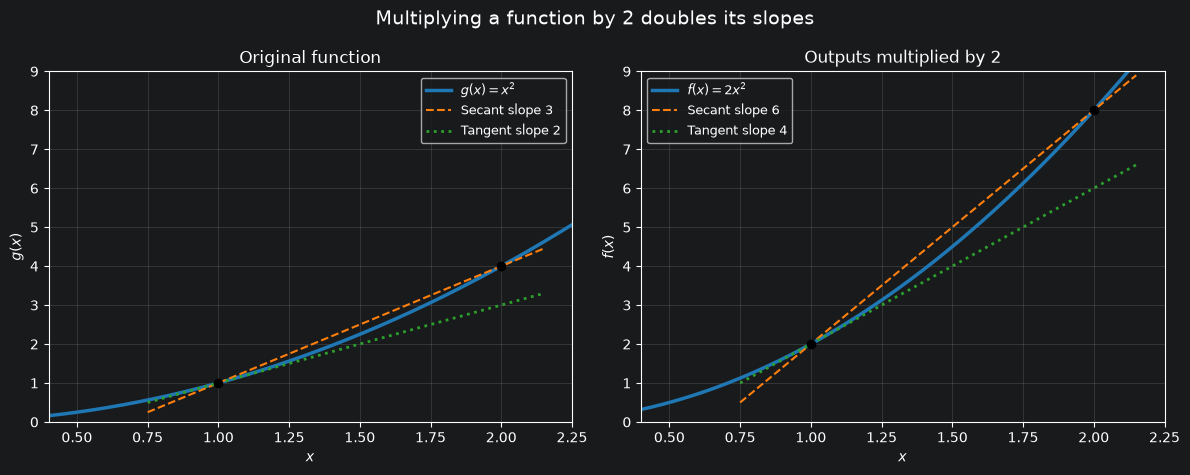

In [2]:
scalar_inputs: np.ndarray = np.linspace(0.4, 2.25, 350)
base_outputs: np.ndarray = scalar_inputs**2
scaled_outputs: np.ndarray = 2.0 * scalar_inputs**2
secant_inputs: np.ndarray = np.linspace(0.75, 2.15, 100)

base_secant: np.ndarray = 1.0 + 3.0 * (secant_inputs - 1.0)
scaled_secant: np.ndarray = 2.0 + 6.0 * (secant_inputs - 1.0)
base_tangent: np.ndarray = 1.0 + 2.0 * (secant_inputs - 1.0)
scaled_tangent: np.ndarray = 2.0 + 4.0 * (secant_inputs - 1.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(scalar_inputs, base_outputs, color="tab:blue", linewidth=2.5,
             label="$g(x)=x^2$")
axes[0].plot(secant_inputs, base_secant, color="tab:orange", linestyle="--",
             label="Secant slope $3$")
axes[0].plot(secant_inputs, base_tangent, color="tab:green", linestyle=":", linewidth=2,
             label="Tangent slope $2$")
axes[0].scatter([1, 2], [1, 4], color="black", zorder=3)
axes[0].set(title="Original function", xlabel="$x$", ylabel="$g(x)$", xlim=(0.4, 2.25),
            ylim=(0, 9))
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=9)

axes[1].plot(scalar_inputs, scaled_outputs, color="tab:blue", linewidth=2.5,
             label="$f(x)=2x^2$")
axes[1].plot(secant_inputs, scaled_secant, color="tab:orange", linestyle="--",
             label="Secant slope $6$")
axes[1].plot(secant_inputs, scaled_tangent, color="tab:green", linestyle=":", linewidth=2,
             label="Tangent slope $4$")
axes[1].scatter([1, 2], [2, 8], color="black", zorder=3)
axes[1].set(title="Outputs multiplied by $2$", xlabel="$x$", ylabel="$f(x)$",
            xlim=(0.4, 2.25), ylim=(0, 9))
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=9)

fig.suptitle("Multiplying a function by $2$ doubles its slopes", fontsize=14)
fig.tight_layout()
plt.show()

### Why the scalar rule works

Apply the derivative definition to $f(x)=c\,g(x)$:

$$
\begin{aligned}
f'(x)
&=
\lim_{\Delta x\to0}
\frac{f(x+\Delta x)-f(x)}{\Delta x} \\
&=
\lim_{\Delta x\to0}
\frac{c\,g(x+\Delta x)-c\,g(x)}{\Delta x} \\
&=
c\lim_{\Delta x\to0}
\frac{g(x+\Delta x)-g(x)}{\Delta x} \\
&=
c\,g'(x).
\end{aligned}
$$

The constant $c$ factors out because it stays fixed while $\Delta x$ approaches zero.

#### Why the final limit becomes $g'(x)$

Recall the derivative definition for the function $g$:

$$
g'(x)
:=
\lim_{\Delta x\to0}
\frac{g(x+\Delta x)-g(x)}{\Delta x}.
$$

The symbol $:=$ means **is defined to be**. Now compare that definition with the limit in the second-to-last line:

$$
c\underbrace{
\lim_{\Delta x\to0}
\frac{g(x+\Delta x)-g(x)}{\Delta x}
}_{\text{this entire limit is }g'(x)}.
$$

They are the same expression, symbol for symbol. Therefore, we replace the entire limit with its name, $g'(x)$:

$$
c\underbrace{
\lim_{\Delta x\to0}
\frac{g(x+\Delta x)-g(x)}{\Delta x}
}_{g'(x)}
=
c\,g'(x).
$$

So the last step does not perform another algebraic calculation. It recognizes the derivative-definition pattern:

$$
\boxed{
\lim_{\Delta x\to0}
\frac{g(x+\Delta x)-g(x)}{\Delta x}
=g'(x).
}
$$

For example, if $g(x)=x^2$, then $g'(x)=2x$. Consequently,

$$
\frac{d}{dx}[c x^2]
=c\,g'(x)
=c(2x)
=2cx.
$$

### Takeaway

For any constant $c$,

$$
\boxed{\frac{d}{dx}\left[c\,g(x)\right]=c\,g'(x).}
$$

Geometrically, multiplying all heights by $c$ multiplies every secant and tangent slope by $c$. For example,

$$
\frac{d}{dx}(2x^2)=2\frac{d}{dx}(x^2)=2(2x)=4x.
$$

## Video 3 — The sum rule

Suppose a function is the sum of two differentiable functions:

$$
f(x)=g(x)+h(x).
$$

The **sum rule** says that its derivative is the sum of their derivatives:

$$
\boxed{f'(x)=g'(x)+h'(x).}
$$

Each function contributes its own rate of change to the rate of change of the total.

### A child moving inside a boat

Imagine a boat and a child moving in the same direction:

- $x_b$ is the distance traveled by the boat relative to Earth;
- $x_c$ is the distance traveled by the child relative to the boat;
- $x_{\text{total}}$ is the child's distance relative to Earth.

The distances add:

$$
x_{\text{total}}=x_b+x_c.
$$

For example, if the boat moves $10$ meters while the child moves $2$ meters forward inside it, then the child moves

$$
10+2=12\text{ meters}
$$

relative to Earth.

The same addition applies to velocities. If the boat travels at $0.6$ meters per second and the child runs forward at $0.05$ meters per second relative to the boat, then

$$
v_{\text{total}}=0.6+0.05=0.65\text{ meters per second}.
$$

Direction matters: this addition uses the same direction as positive. If the child ran in the opposite direction, the child's velocity would have the opposite sign.

### Distances and their slopes

For the constant velocities in the example, distance is velocity multiplied by time. The slope of each line is its velocity, and the slope of the total-distance line is the sum of the other two slopes.

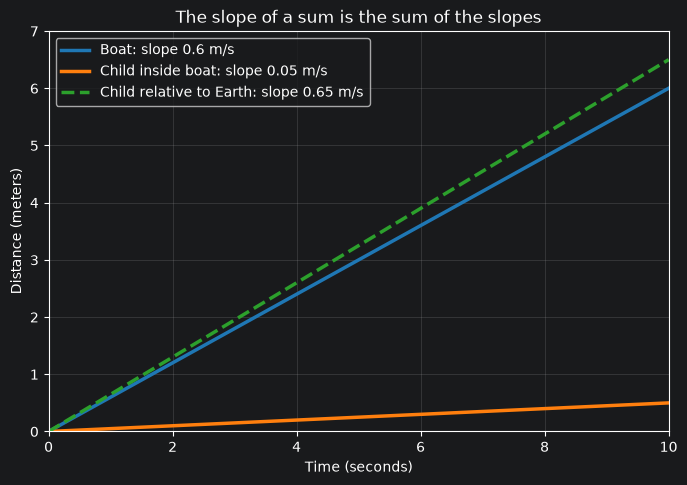

In [3]:
sum_rule_times: np.ndarray = np.linspace(0.0, 10.0, 250)
boat_velocity: float = 0.6
child_velocity: float = 0.05
child_earth_velocity: float = boat_velocity + child_velocity

boat_distances: np.ndarray = boat_velocity * sum_rule_times
child_relative_distances: np.ndarray = child_velocity * sum_rule_times
child_earth_distances: np.ndarray = child_earth_velocity * sum_rule_times

fig, ax = plt.subplots(figsize=(8, 5.2))
ax.plot(sum_rule_times, boat_distances, color="tab:blue", linewidth=2.5,
        label=rf"Boat: slope ${boat_velocity}$ m/s")
ax.plot(sum_rule_times, child_relative_distances, color="tab:orange", linewidth=2.5,
        label=rf"Child inside boat: slope ${child_velocity}$ m/s")
ax.plot(sum_rule_times, child_earth_distances, color="tab:green", linestyle="--", linewidth=2.5,
        label=rf"Child relative to Earth: slope ${child_earth_velocity}$ m/s")
ax.set(
    title="The slope of a sum is the sum of the slopes",
    xlabel="Time (seconds)",
    ylabel="Distance (meters)",
    xlim=(0, 10),
    ylim=(0, 7),
)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

### From average velocities to derivatives

Over the same time interval $\Delta t$, the distance changes satisfy

$$
\Delta x_{\text{total}}=\Delta x_b+\Delta x_c.
$$

Divide every term by the same $\Delta t$:

$$
\frac{\Delta x_{\text{total}}}{\Delta t}
=
\frac{\Delta x_b}{\Delta t}
+
\frac{\Delta x_c}{\Delta t}.
$$

These fractions are the average velocities over that interval. Letting $\Delta t\to0$ turns them into instantaneous velocities:

$$
v_{\text{total}}=v_b+v_c.
$$

This is the sum rule expressed through motion: when positions add, their rates of change add as well.

### Why the sum rule works

Starting from $f(x)=g(x)+h(x)$, apply the difference quotient:

$$
\begin{aligned}
f'(x)
&=
\lim_{\Delta x\to0}
\frac{f(x+\Delta x)-f(x)}{\Delta x} \\
&=
\lim_{\Delta x\to0}
\frac{[g(x+\Delta x)+h(x+\Delta x)]-[g(x)+h(x)]}{\Delta x} \\
&=
\lim_{\Delta x\to0}
\left[
\frac{g(x+\Delta x)-g(x)}{\Delta x}
+
\frac{h(x+\Delta x)-h(x)}{\Delta x}
\right] \\
&=
g'(x)+h'(x).
\end{aligned}
$$

The final step uses the fact that the limit of a sum is the sum of the limits when both derivatives exist.

### Takeaway

For differentiable functions $g$ and $h$,

$$
\boxed{\frac{d}{dx}[g(x)+h(x)]=g'(x)+h'(x).}
$$

For example,

$$
\frac{d}{dx}(x^2+e^x)=2x+e^x.
$$

Different parts of a sum can be differentiated separately and then added.

## Video 4 — The product rule

Suppose a function is the product of two differentiable functions:

$$
f(x)=g(x)h(x).
$$

Its derivative is **not** simply $g'(x)h'(x)$. The **product rule** is

$$
\boxed{f'(x)=g'(x)h(x)+g(x)h'(x).}
$$

A useful memory aid from the lecture is to let the derivative “hit” one factor at a time:

1. differentiate $g$ and leave $h$ unchanged;
2. leave $g$ unchanged and differentiate $h$;
3. add the two results.

### A growing rectangular house

Imagine two groups constructing perpendicular walls:

- $g(t)$ is the side-wall length at time $t$;
- $h(t)$ is the front-wall length at time $t$.

Following the lecture diagram, $g(t)$ is the vertical dimension and $h(t)$ is the horizontal dimension. Viewed from above, the enclosed rectangular area is

$$
y=f(t)=g(t)h(t).
$$

After a short time $\Delta t$, suppose the dimensions increase by $\Delta g(t)$ and $\Delta h(t)$. The new area is

$$
[g(t)+\Delta g(t)][h(t)+\Delta h(t)].
$$

The question is how quickly the area changes when both wall lengths are changing.

### Decomposing the change in area

Expanding the new rectangle gives

$$
[g(t)+\Delta g(t)][h(t)+\Delta h(t)]
=
g(t)h(t)+\Delta g(t)h(t)+g(t)\Delta h(t)+\Delta g(t)\Delta h(t).
$$

After subtracting the original area $g(t)h(t)$, the area change is

$$
\Delta f(t)
=
\Delta g(t)h(t)+g(t)\Delta h(t)+\Delta g(t)\Delta h(t).
$$

It consists of two thin strips and one tiny corner rectangle. The following diagram follows the lecture's orientation and notation but uses illustrative dimensions because the transcript does not provide numerical wall lengths.

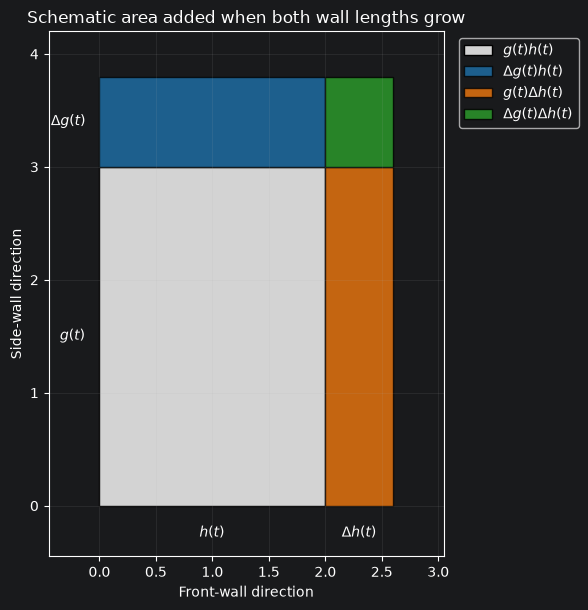

In [4]:
from matplotlib.patches import Rectangle

house_side_length: float = 3.0
house_front_length: float = 2.0
house_side_increment: float = 0.8
house_front_increment: float = 0.6

fig, ax = plt.subplots(figsize=(7.5, 6.2))
original_area = Rectangle((0, 0), house_front_length, house_side_length,
                          facecolor="lightgray", edgecolor="black", label="$g(t)h(t)$")
top_strip = Rectangle((0, house_side_length), house_front_length, house_side_increment,
                      facecolor="tab:blue", alpha=0.75, edgecolor="black",
                      label="$\\Delta g(t)h(t)$")
right_strip = Rectangle((house_front_length, 0), house_front_increment, house_side_length,
                        facecolor="tab:orange", alpha=0.75, edgecolor="black",
                        label="$g(t)\\Delta h(t)$")
corner_area = Rectangle((house_front_length, house_side_length), house_front_increment,
                        house_side_increment, facecolor="tab:green", alpha=0.8,
                        edgecolor="black", label="$\\Delta g(t)\\Delta h(t)$")

for area_patch in [original_area, top_strip, right_strip, corner_area]:
    ax.add_patch(area_patch)

ax.annotate("$h(t)$", (house_front_length / 2, -0.18), ha="center", va="top")
ax.annotate("$g(t)$", (-0.12, house_side_length / 2), ha="right", va="center")
ax.annotate("$\\Delta h(t)$", (house_front_length + house_front_increment / 2, -0.18),
            ha="center", va="top")
ax.annotate("$\\Delta g(t)$", (-0.12, house_side_length + house_side_increment / 2),
            ha="right", va="center")
ax.set(
    title="Schematic area added when both wall lengths grow",
    xlabel="Front-wall direction",
    ylabel="Side-wall direction",
    xlim=(-0.45, 3.05),
    ylim=(-0.45, 4.2),
)
ax.set_aspect("equal")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

### From area change to the product rule

Divide the area change by the elapsed time $\Delta t$:

$$
\begin{aligned}
\frac{\Delta f(t)}{\Delta t}
&=
\frac{\Delta g(t)h(t)+g(t)\Delta h(t)+\Delta g(t)\Delta h(t)}{\Delta t} \\
&=
\frac{\Delta g(t)}{\Delta t}h(t)
+g(t)\frac{\Delta h(t)}{\Delta t}
+\frac{\Delta g(t)\Delta h(t)}{\Delta t}.
\end{aligned}
$$

Now let $\Delta t\to0$:

- $\frac{\Delta g(t)}{\Delta t}\to g'(t)$;
- $\frac{\Delta h(t)}{\Delta t}\to h'(t)$;
- $\Delta h(t)\to0$.

The corner term can be rewritten as

$$
\frac{\Delta g(t)\Delta h(t)}{\Delta t}
=
\frac{\Delta g(t)}{\Delta t}\Delta h(t)
\to
g'(t)\cdot0=0.
$$

The two thin-strip contributions remain, giving

$$
\boxed{f'(t)=g'(t)h(t)+g(t)h'(t).}
$$

### Why the tiny corner disappears

The corner area $\Delta g(t)\Delta h(t)$ contains **two** small changes multiplied together. When divided by $\Delta t$, one change contributes a finite rate while the other still shrinks to zero.

This does not mean the corner area is exactly zero for a finite time interval. It means its contribution to the instantaneous rate approaches zero as $\Delta t$ approaches zero.

### Takeaway

For differentiable functions $g$ and $h$,

$$
\boxed{\frac{d}{dx}[g(x)h(x)]=g'(x)h(x)+g(x)h'(x).}
$$

For example, let $g(x)=x^2$ and $h(x)=e^x$. Then

$$
\begin{aligned}
\frac{d}{dx}[x^2e^x]
&=(2x)e^x+x^2(e^x) \\
&=e^x(2x+x^2).
\end{aligned}
$$

Differentiate one factor at a time, leave the other unchanged, and add the two contributions.

## Video 5 — The chain rule

The **chain rule** differentiates a composition: one function applied to the output of another function.

Start with an inner function $h(t)$ and apply an outer function $g$ to its output:

$$
y=g(h(t)).
$$

A change in $t$ first changes $h$, and that change in $h$ then changes $g$. The total rate is the product of those two rates:

$$
\boxed{\frac{dy}{dt}=\frac{dg}{dh}\frac{dh}{dt}.}
$$

It is called the chain rule because a change can pass through a chain of functions.

### Leibniz notation shows the chain

For

$$
y=g(h(t)),
$$

Leibniz notation gives

$$
\frac{dy}{dt}
=
\frac{dg}{dh}\frac{dh}{dt}.
$$

The repeated $dh$ suggests how the intermediate change connects the two rates:

$$
\frac{dg}{dh}\frac{dh}{dt}
\longrightarrow
\frac{dg}{dt}.
$$

This cancellation is a useful memory aid. The actual derivative rule is justified by taking limits of ratios of small changes.

### Lagrange notation: evaluate at the correct input

In prime notation,

$$
\frac{dh}{dt}=h'(t).
$$

The derivative of the outer function is evaluated at the value entering that function. Since the input to $g$ is $h(t)$,

$$
\frac{dg}{dh}=g'(h(t)),
$$

not $g'(t)$. Therefore,

$$
\boxed{\frac{d}{dt}g(h(t))=g'(h(t))h'(t).}
$$

A reliable procedure is:

1. differentiate the outer function while leaving its input unchanged;
2. multiply by the derivative of the inner function.

### A longer chain of functions

Now compose three functions:

$$
y=f(g(h(t))).
$$

A change travels through the chain

$$
t\longrightarrow h(t)\longrightarrow g(h(t))\longrightarrow f(g(h(t))).
$$

In Leibniz notation,

$$
\frac{dy}{dt}
=
\frac{df}{dg}\frac{dg}{dh}\frac{dh}{dt}.
$$

In prime notation, each derivative must receive the correct input:

$$
\boxed{
\frac{d}{dt}f(g(h(t)))
=
f'(g(h(t)))\,g'(h(t))\,h'(t).
}
$$

More composed functions produce more factors in the chain.

### Driving up a mountain

Let

- $t$ represent time;
- $h(t)$ represent the car's height on the mountain;
- $T(h)$ represent the temperature at height $h$.

As time passes, the car's height changes at the rate

$$
\frac{dh}{dt}.
$$

Temperature changes with height at the rate

$$
\frac{dT}{dh}.
$$

Because temperature depends on time through height, the temperature experienced by the driver is the composition

$$
T(h(t)).
$$

The chain rule gives

$$
\boxed{\frac{dT}{dt}=\frac{dT}{dh}\frac{dh}{dt}.}
$$

The units also form a chain:

$$
\frac{\text{degrees}}{\text{meter}}
\cdot
\frac{\text{meters}}{\text{second}}
=
\frac{\text{degrees}}{\text{second}}.
$$

### From small changes to derivatives

A small time change $\Delta t$ causes a height change $\Delta h$, which causes a temperature change $\Delta T$:

$$
\Delta t\longrightarrow\Delta h\longrightarrow\Delta T.
$$

For nonzero $\Delta h$, the finite-change ratios satisfy

$$
\frac{\Delta T}{\Delta t}
=
\frac{\Delta T}{\Delta h}
\frac{\Delta h}{\Delta t}.
$$

As $\Delta t\to0$, the corresponding changes $\Delta h$ and $\Delta T$ also approach zero. Under the differentiability assumptions of the chain rule, the ratios approach derivatives:

$$
\frac{dT}{dt}
=
\frac{dT}{dh}
\frac{dh}{dt}.
$$

This corrects two slips in the spoken transcript: the left side is $\Delta T/\Delta t$ before the limit and $dT/dt$ after it, where uppercase $T$ denotes temperature and lowercase $t$ denotes time.

### A schematic three-dimensional view

The lecture visualizes time, height, and temperature on three axes. The following plot uses illustrative functions and values because the transcript provides no numerical mountain data:

$$
h(t)=t^2
\qquad\text{and}\qquad
T(h)=25-1.5h.
$$

The curve traces how one time determines one height, which then determines one temperature.

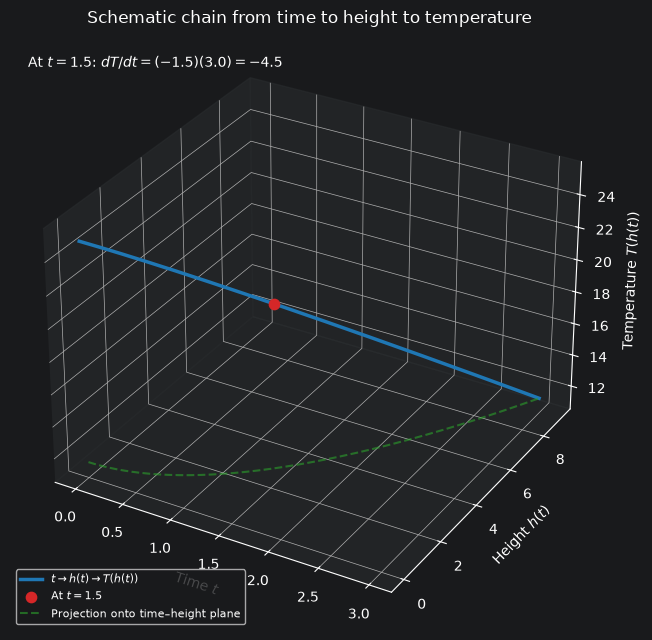

In [5]:
chain_times: np.ndarray = np.linspace(0.0, 3.0, 300)
chain_heights: np.ndarray = chain_times**2
chain_temperatures: np.ndarray = 25.0 - 1.5 * chain_heights
chain_time_point: float = 1.5
chain_height_point: float = chain_time_point**2
chain_temperature_point: float = 25.0 - 1.5 * chain_height_point
chain_height_rate: float = 2.0 * chain_time_point
chain_temperature_height_rate: float = -1.5
chain_temperature_time_rate: float = chain_temperature_height_rate * chain_height_rate

fig = plt.figure(figsize=(8.5, 6.5))
ax = fig.add_subplot(111, projection="3d")
ax.plot(chain_times, chain_heights, chain_temperatures, color="tab:blue", linewidth=2.5,
        label="$t \\to h(t) \\to T(h(t))$")
ax.scatter([chain_time_point], [chain_height_point], [chain_temperature_point],
           color="tab:red", s=55, label=rf"At $t={chain_time_point}$")
ax.plot(chain_times, chain_heights, np.full_like(chain_times, chain_temperatures.min()),
        color="tab:green", linestyle="--", alpha=0.6, label="Projection onto time–height plane")
ax.set(
    title="Schematic chain from time to height to temperature",
    xlabel="Time $t$",
    ylabel="Height $h(t)$",
    zlabel="Temperature $T(h(t))$",
)
ax.text2D(
    0.03,
    0.94,
    rf"At $t={chain_time_point}$: $dT/dt=({chain_temperature_height_rate})({chain_height_rate})"
    rf"={chain_temperature_time_rate}$",
    transform=ax.transAxes,
)
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

### Takeaway

For a two-function composition,

$$
\boxed{\frac{d}{dt}g(h(t))=g'(h(t))h'(t).}
$$

For example,

$$
\begin{aligned}
\frac{d}{dt}e^{t^2}
&=e^{t^2}\frac{d}{dt}(t^2) \\
&=2t\,e^{t^2}.
\end{aligned}
$$

The central question is always: **what value is entering each function?** Differentiate from the outside inward, evaluating each derivative at its actual input.